## Code
[https://github.com/rovinor4/Praktikum-Dasar-Kecerdasan-Artifisial/tree/main/Tugas%20Mandiri%20-%20Modul%208%20Algoritma%20Hill%20Climbing](https://github.com/rovinor4/Praktikum-Dasar-Kecerdasan-Artifisial/tree/main/Tugas%20Mandiri%20-%20Modul%208%20Algoritma%20Hill%20Climbing)
## Penjelasan Dan Output Soal 1

In [30]:
import math
import random

import matplotlib.pyplot as plt

Kode ini mengimpor library yang dibutuhkan. math digunakan untuk menghitung jarak Euclidean, random digunakan untuk mengacak rute awal, dan matplotlib.pyplot digunakan untuk menampilkan visualisasi rute dalam bentuk grafik.

In [31]:
cities = [
    (0, 0),
    (2, 3),
    (5, 1),
    (6, 4),
    (8, 0),
    (1, 7),
    (4, 6)
]

Kode ini mendefinisikan daftar kota dalam bentuk koordinat (x, y). Setiap elemen pada list cities mewakili posisi satu kota yang akan dikunjungi dalam proses pencarian rute.

In [32]:
def total_distance(route):
    distance = 0

    for i in range(len(route)):
        city_now = cities[route[i]]
        city_next = cities[route[(i + 1) % len(route)]]
        distance += euclidean_distance(city_now, city_next)

    return distance

Fungsi total_distance(route) digunakan untuk menghitung total jarak dari sebuah rute. Fungsi ini menjumlahkan jarak antar kota secara berurutan, termasuk jarak dari kota terakhir kembali ke kota pertama.

In [33]:
def get_best_neighbor(route):
    best_neighbor = route[:]
    best_distance = total_distance(route)

    for i in range(len(route)):
        for j in range(i + 1, len(route)):
            neighbor = route[:]
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

            neighbor_distance = total_distance(neighbor)

            if neighbor_distance < best_distance:
                best_neighbor = neighbor
                best_distance = neighbor_distance

    return best_neighbor, best_distance

Fungsi get_best_neighbor(route) digunakan untuk mencari rute tetangga terbaik. Caranya adalah dengan menukar posisi dua kota dalam rute, lalu memilih rute dengan total jarak paling kecil.

In [34]:
def hill_climbing():
    current_route = list(range(len(cities)))
    random.shuffle(current_route)

    initial_route = current_route[:]
    initial_distance = total_distance(initial_route)

    while True:
        neighbor, neighbor_distance = get_best_neighbor(current_route)
        current_distance = total_distance(current_route)

        if neighbor_distance < current_distance:
            current_route = neighbor
        else:
            print("Solusi optimal lokal telah ditemukan")
            break

    return initial_route, initial_distance, current_route, total_distance(current_route)


Fungsi hill_climbing() menjalankan algoritma Hill Climbing. Rute awal dibuat secara acak, lalu program terus mencari tetangga yang lebih baik sampai tidak ditemukan rute dengan jarak yang lebih pendek. Jika sudah tidak ada perbaikan, program berhenti pada solusi optimal lokal.

In [35]:
def route_to_coordinates(route):
    x = [cities[i][0] for i in route]
    y = [cities[i][1] for i in route]

    x.append(cities[route[0]][0])
    y.append(cities[route[0]][1])

    return x, y

Fungsi route_to_coordinates(route) mengubah urutan rute menjadi daftar koordinat x dan y. Kota pertama ditambahkan kembali di akhir agar grafik membentuk rute tertutup.

In [36]:
def euclidean_distance(city1, city2):
    return math.sqrt((city1[0] - city2[0]) ** 2 + (city1[1] - city2[1]) ** 2)

Fungsi euclidean_distance(city1, city2) menghitung jarak lurus antara dua kota. Rumus yang digunakan adalah rumus jarak Euclidean berdasarkan selisih koordinat x dan y.

In [37]:
def plot_route(route, title):
    x, y = route_to_coordinates(route)

    plt.figure(figsize=(7, 5))
    plt.plot(x, y, marker="o")

    for i, city_index in enumerate(route):
        plt.text(cities[city_index][0], cities[city_index][1], f"K{city_index}")

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

Fungsi plot_route(route, title) digunakan untuk menampilkan visualisasi rute. Setiap kota ditampilkan sebagai titik, diberi label, lalu dihubungkan dengan garis sesuai urutan rutenya.

In [38]:
initial_route, initial_distance, best_route, best_distance = hill_climbing()

Solusi optimal lokal telah ditemukan


Kode ini menjalankan fungsi hill_climbing(). Hasilnya disimpan ke dalam variabel rute awal, jarak awal, rute terbaik, dan jarak terbaik setelah proses optimasi.

Rute awal:
[1, 4, 6, 3, 0, 5, 2]

Rute terbaik hasil optimasi:
[1, 5, 6, 3, 4, 2, 0]

Total jarak sebelum optimasi:
41.85

Total jarak sesudah optimasi:
26.45


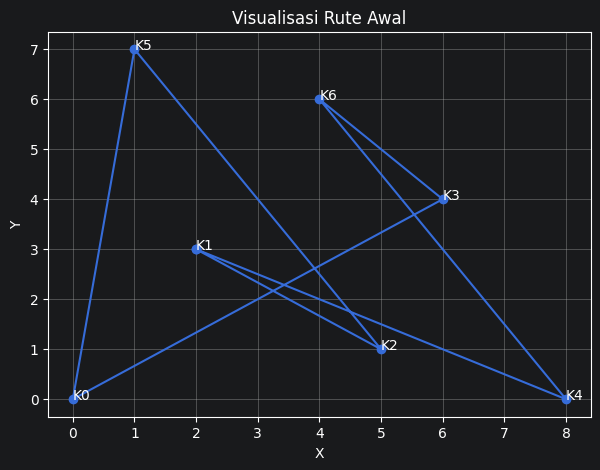

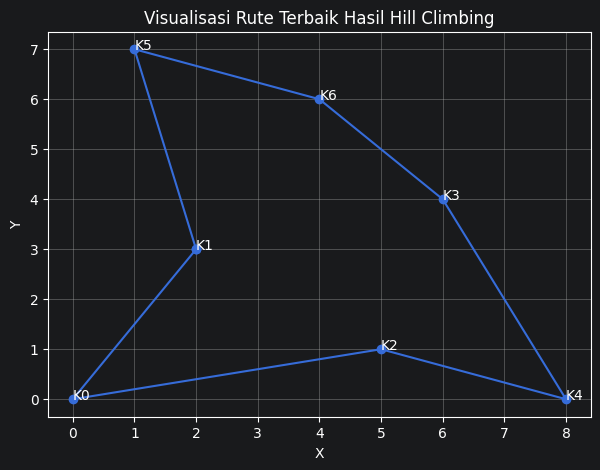

In [39]:
print("Rute awal:")
print(initial_route)

print("\nRute terbaik hasil optimasi:")
print(best_route)

print("\nTotal jarak sebelum optimasi:")
print(round(initial_distance, 2))

print("\nTotal jarak sesudah optimasi:")
print(round(best_distance, 2))

plot_route(initial_route, "Visualisasi Rute Awal")
plot_route(best_route, "Visualisasi Rute Terbaik Hasil Hill Climbing")

Kode ini menampilkan hasil akhir program, yaitu rute awal, rute terbaik, total jarak sebelum optimasi, dan total jarak setelah optimasi. Setelah itu, program menampilkan dua grafik untuk membandingkan rute awal dan rute terbaik hasil Hill Climbing.